In [3]:
import json
from pathlib import Path

from upsetplot import from_contents, plot
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, auc
import matplotlib.pyplot as plt

In [9]:
def get_video_logit_average(preds_path):
    with open(preds_path) as preds_file:
        preds_dict = json.load(preds_file)

        video_dict = {}

        #video_list = []

        for index, frame in enumerate(preds_dict["paths"]):
            video_name = str(Path(frame).parent)

            if video_name in video_dict.keys():
                #video_dict[video_name]["labels"].append(preds_dict["labels"][index])
                video_dict[video_name]["preds"].append(preds_dict["preds"][index])
                video_dict[video_name]["logits"].append(preds_dict["logits"][index])

            else:
                video_dict[video_name] = {
                    "label": preds_dict["labels"][index],
                    "preds": [preds_dict["preds"][index]],
                    "logits": [preds_dict["logits"][index]],
                }



        average_dict = {}

        for video, values in video_dict.items():

            logits_left = [e[0] for e in values["logits"]]
            logits_right = [e[1] for e in values["logits"]]

            left_mean = np.mean(logits_left)
            right_mean = np.mean(logits_right)
            

            average_dict[video] = {
                "label": values["label"],
                "pred": np.mean(values["preds"]),
                "logits": [left_mean, right_mean],
            }
        return average_dict

# DF40_FS
### Clip base (df40-all-ff_cdf)

In [11]:
a = get_video_logit_average("exps_old/FSAll_cdf/clip_base/train_on_df40-all-ff/preds/2026-02-20T16-46-44A.json")

#with open("analysis/selected_models_preds/fs_all/clip_base_df40-all-ff.json", "w+") as f:
#    json.dump(a, f, indent=4)

In [4]:
labels = []
raw_preds = []

with open("exps/FSAll_cdf/i3d/train_on_df40-all-ff/preds/video-level/2026-02-22T23-07-59A.json.json") as preds_file:
        preds_dict = json.load(preds_file)

        labels = [values["label"] for video, values in preds_dict.items()]
        raw_preds = [values["pred"] for video, values in preds_dict.items()]


fpr, tpr, thresholds = roc_curve(labels, raw_preds)

target_tpr = 0.6
idx = np.argmax(tpr >= target_tpr)

fpr_at_90 = fpr[idx]
threshold_at_90 = thresholds[idx]

print(f"Pour détecter {tpr[idx]*100:.1f}% des deepfakes :")
print(f"-> Le taux de fausses alarmes (FPR) sera de {fpr_at_90*100:.1f}%")
print(f"-> Il faudra régler le seuil de décision du modèle à {threshold_at_90:.100}")

Pour détecter 60.0% des deepfakes :
-> Le taux de fausses alarmes (FPR) sera de 4.6%
-> Il faudra régler le seuil de décision du modèle à 0.999936401844024658203125


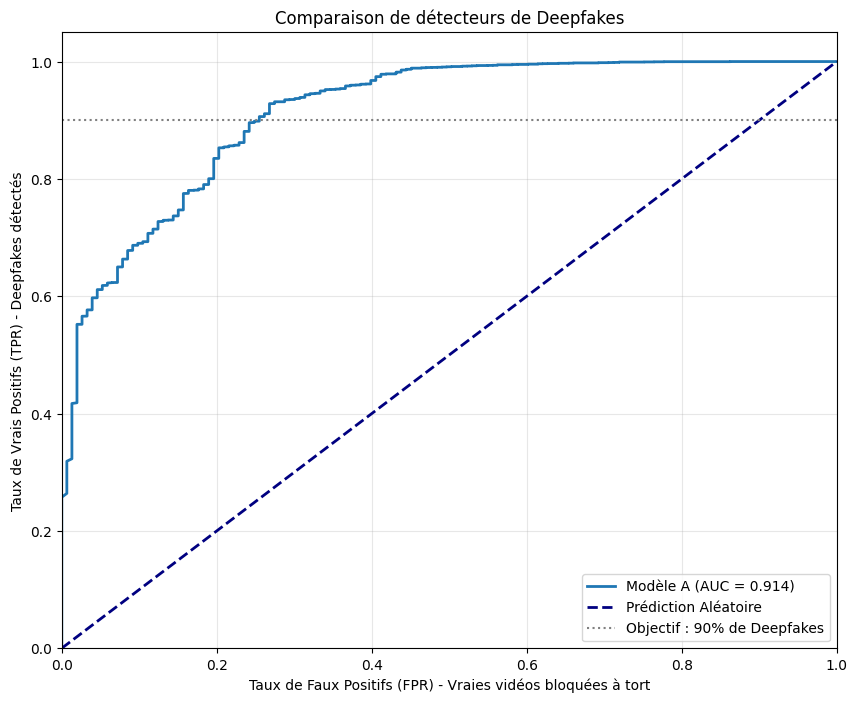

In [36]:
# Exemple pour 3 modèles (vous pouvez l'étendre à vos 16 modèles)
# y_true = Vos vraies étiquettes (0 = Vraie vidéo, 1 = Deepfake)
# probas_modele_1, probas_modele_2, etc = Les probabilités de la classe "1" (Deepfake) pour chaque modèle

predictions_modeles = {
    "Modèle A": raw_preds,
}

plt.figure(figsize=(10, 8))

# On boucle sur chaque modèle pour tracer sa courbe
for nom_modele, probas in predictions_modeles.items():
    fpr, tpr, thresholds = roc_curve(labels, probas)
    roc_auc = auc(fpr, tpr)
    
    # On trace la courbe avec son AUC dans la légende
    plt.plot(fpr, tpr, lw=2, label=f'{nom_modele} (AUC = {roc_auc:.3f})')

# On trace la ligne du "Modèle Aléatoire" (la pire performance possible)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Prédiction Aléatoire')

# Petite astuce : on peut tracer une ligne horizontale à 90% de TPR
# pour voir quel modèle croise cette ligne le plus à GAUCHE possible (FPR le plus bas)
plt.axhline(y=0.90, color='gray', linestyle=':', label='Objectif : 90% de Deepfakes')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR) - Vraies vidéos bloquées à tort')
plt.ylabel('Taux de Vrais Positifs (TPR) - Deepfakes détectés')
plt.title('Comparaison de détecteurs de Deepfakes')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Afficher ou sauvegarder le graphique
plt.show()

array([1, 1, 1, ..., 1, 1, 1], shape=(4866,))

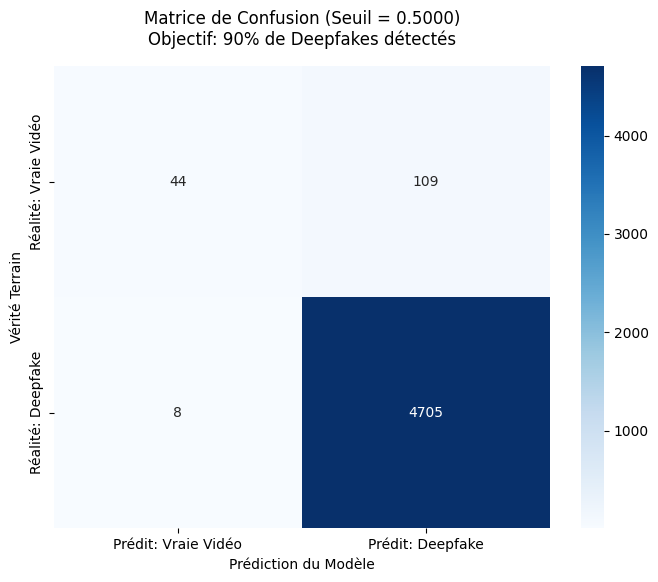

In [49]:
seuil_choisi = 0.5

# 2. Créer les nouvelles prédictions binaires basées sur CE seuil
# Si proba >= seuil -> 1 (Deepfake), sinon -> 0 (Vraie vidéo)
y_pred_sur_mesure = (np.array(raw_preds) >= seuil_choisi).astype(int)

# 3. Calculer la matrice de confusion brute
cm = confusion_matrix(labels, y_pred_sur_mesure)

# 4. Créer un bel affichage visuel
plt.figure(figsize=(8, 6))
# 'fmt="d"' permet d'afficher des nombres entiers (pas d'écriture scientifique)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit: Vraie Vidéo', 'Prédit: Deepfake'],
            yticklabels=['Réalité: Vraie Vidéo', 'Réalité: Deepfake'])

plt.title(f'Matrice de Confusion (Seuil = {seuil_choisi:.4f})\nObjectif: 90% de Deepfakes détectés', pad=15)
plt.ylabel('Vérité Terrain')
plt.xlabel('Prédiction du Modèle')
plt.show()

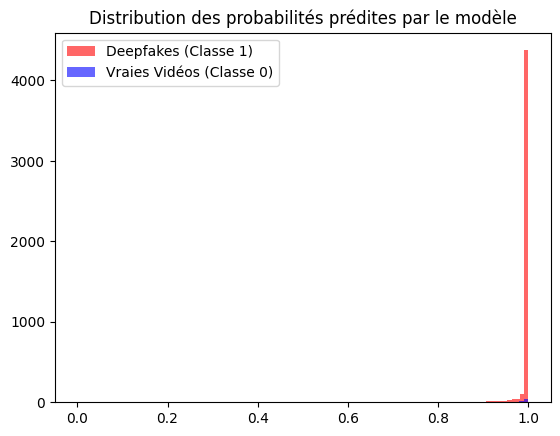

In [62]:
probs_array = np.array(raw_preds)
labels_np = np.array(labels)

# On sépare les probabilités selon la vraie classe
plt.hist(probs_array[labels_np == 1], bins=100, alpha=0.6, color='red', label='Deepfakes (Classe 1)')
plt.hist(probs_array[labels_np == 0], bins=100, alpha=0.6, color='blue', label='Vraies Vidéos (Classe 0)')

# Affichage
plt.title("Distribution des probabilités prédites par le modèle")
plt.legend()
plt.show()

In [32]:
idx = np.argmax(tpr >= target_tpr)

fpr_at_90 = fpr[idx]

display(fpr_at_90)

np.float64(0.1895424836601307)

In [ ]:

# 1. On identifie les vidéos en erreur pour chaque détecteur
# On crée un dictionnaire où la clé est le nom du détecteur 
# et la valeur est la liste des noms (ou IDs) des vidéos où il s'est trompé
errors_by_detector = {}

for name, df in dfs.items():
    # Masque des erreurs (prédit != réel)
    thresh = best_thresholds[name]
    pred_bin = (df['raw_pred_mean'] > 0.5).astype(int) # todo threshold
    mask_error = pred_bin != df['label']
    
    # On stocke les noms des vidéos qui sont dans ce masque
    errors_by_detector[name] = df.index[mask_error].tolist()

# 2. On transforme cela au format attendu par UpSetPlot
data_for_upset = from_contents(errors_by_detector)

# 3. Affichage du graphique
plt.figure(figsize=(15, 8))
plot(data_for_upset, show_counts=True, sort_by="cardinality")
plt.title("Error intersection by detectors")
plt.show()

/tmp/ipykernel_82627/3959271242.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Vraie Classe', y='Probabilité Prédite', data=df,


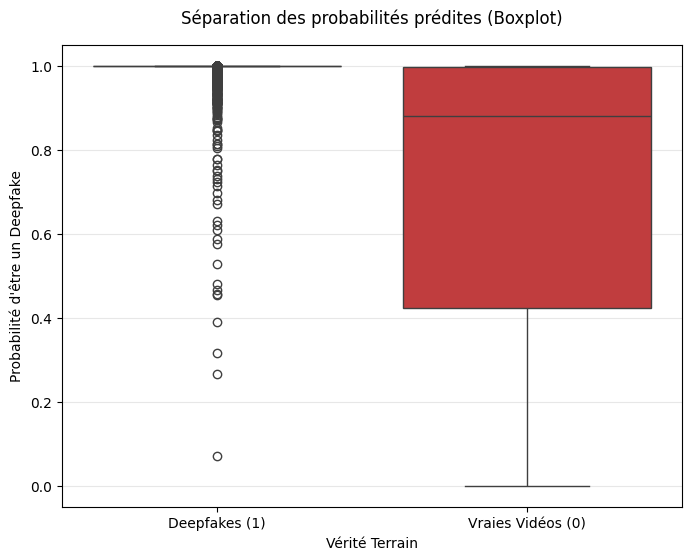

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. On transforme vos listes en un tableau de données (DataFrame) structuré
df = pd.DataFrame({
    'Vraie Classe': labels,
    'Probabilité Prédite': raw_preds
})

# 2. On renomme les 0 et 1 pour avoir une belle légende
df['Vraie Classe'] = df['Vraie Classe'].map({0: 'Vraies Vidéos (0)', 1: 'Deepfakes (1)'})

# 3. Création du graphique
plt.figure(figsize=(8, 6))

# On trace le boxplot
sns.boxplot(x='Vraie Classe', y='Probabilité Prédite', data=df, 
            palette=['#1f77b4', '#d62728'], # Bleu et Rouge
            showfliers=True) # showfliers=True affiche les points aberrants

plt.title('Séparation des probabilités prédites (Boxplot)', pad=15)
plt.ylabel('Probabilité d\'être un Deepfake')
plt.xlabel('Vérité Terrain')
plt.grid(axis='y', alpha=0.3)

plt.show()